In [56]:
import control as ct
import matplotlib.pyplot as plt
import math
import numpy as np
import cvxpy as cp
import networkx as ntx
from scipy.integrate import solve_ivp
from scipy import signal
from utils.lmis_ts import *

rng = np.random.default_rng()

In [57]:
# simulation time
time = 25
eta = 1
eps = 1e-9
x0 = np.array([0.5, 0.88, -0.25, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

# normal cases
z_interval = [
    [0.2, 1],
    [.1667, 0.5],
    [-1, 1],
    [-4*math.pi, 4*math.pi]
]
zeta_interval = [
    [-2*math.pi, 2*math.pi]
]

# hyperplanes
a = np.array([
    [1, -1, 0, 0, 0, 0, 0, 0],
    [0, 0, 1, -1, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, -1, 0, 0],
    [0, 0, 0, 0, 0, 0, 1, -1],
])
b = 4*math.pi * np.ones(shape=(4*2, 1)) # limits of set D
bR = b/2.0 # limits of set R

In [58]:
# generate combinations for multi-index -> j, k \in \mathbb{I}_{n_z} and l \in \mathbb{I}_{n_zeta}
n_z = len(z_interval)
n_zeta = len(zeta_interval)

interval_size = 2 # Just to make this information explict

# amount_perm = 2*n_z + n_zeta
# _, jkl_perm = permn(np.arange(interval_size), amount_perm) # TODO: handle n_zeta = 0

j_perms, _ = permn(np.arange(interval_size), n_z)
k_perms, _ = permn(np.arange(interval_size), n_z)
l_perms, _ = permn(np.arange(interval_size), n_zeta)

In [59]:
### This functions must be changed for different systems
# Politopic representation
def A_ijl(z: list[np.ndarray], zeta: list[np.ndarray], **kwargs) -> np.ndarray:
    return np.array([
        [0, 1, 0, 0],
        [0, 0, 0, 0],
        [0, 1, 0, 1 + z[0]],
        [0, 2*z[1]*z[2]*z[3], 0, 2*z[1]*z[2]*zeta[0]],
    ])

def C_ijl(z: list[np.ndarray], zeta: list[np.ndarray], **kwargs) -> np.ndarray:
    return np.array([
        [1, 0, 0, 0],
        [0, 0, 1, 0],
    ])

theta_x1 = lambda x1: 3 + 2*math.sin(x1)

# alpha = [x1, x4_hat]
z_alpha = lambda alpha: np.array([
    [1/theta_x1(alpha[0, 0])],
    [1/(1 + theta_x1(alpha[0, 0]))],
    [math.cos(alpha[0, 0])],
    [alpha[1, 0]]
])

In [60]:
A_cell = []
C_cell = []

for j_p in j_perms:
    for l_p in l_perms:
        jl_perm = np.concat([j_p, l_p])

        A_ind = bin_from_perm(jl_perm)
        C_ind = A_ind

        z = []
        for j in range(n_z):
            z.append(z_interval[j][jl_perm[j]])
        
        zeta = []
        for j in range(n_zeta):
            zeta.append(zeta_interval[j][jl_perm[n_z + j]])
        A_cell.append(A_ijl(z, zeta))
        C_cell.append(C_ijl(z, zeta))

In [61]:
j_perms_plus = perm_plus(np.unique(j_perms, axis=0))
k_perms_plus = perm_plus(np.unique(k_perms, axis=0))

j_plus_perms_set = multi_index_permutation(j_perms_plus) # -> this is basically rebuilding j_perms
k_plus_perms_set = multi_index_permutation(k_perms_plus) # -> this is basically rebuilding k_perms

In [62]:
# i can move this functions to a politopic representation utils file

w0_alpha = lambda j, z: ((z_interval[j][1] - z[j]) / (z_interval[j][1] - z_interval[j][0]))
w1_alpha = lambda j, z: 1 - w0_alpha(j, z)

w_alpha = lambda j, z: [w0_alpha(j, z), w1_alpha(j, z)]

def phi_z(F: np.ndarray, z: np.ndarray, b: np.ndarray):
    '''
        ### The parameters are given from the expressions and are used to generate Lmis for Theorem 1 of Coutinho et al.
        R = { x \in RR^n : F@x <= b} \\
        phi(z) = min{ b.T@w: F.T@w = z, w \in RR^f >= 0 }
    '''

    w = cp.Variable((b.shape[0], 1))
    constrains = []

    constrains += [ w >= 0]
    
    constrains += [ F.T@w == z ]

    prob = cp.Problem(cp.Minimize(b.T@w), constraints=constrains)
    result = prob.solve(solver=cp.MOSEK, verbose=False)

    return result

def W_ind(z: np.ndarray[float], J_perm_i) -> float:
    '''
        alpha = [alpha_1, ..., alpha_N}], alpha_1 = [alpha_11, ..., alpha_1{n_{alpha_1}}]` \\
        perm = multiindex permutations \\
        n_prods = number of products
    '''
    
    prod = 1
    for k in range(len(z_interval)): # n_alpha_i
        prod *= w_alpha(k, z)[J_perm_i[k]]
    
    return prod

<>:9: SyntaxWarning: invalid escape sequence '\i'
<>:9: SyntaxWarning: invalid escape sequence '\i'
C:\Users\luiza\AppData\Local\Temp\ipykernel_2028\1770042469.py:9: SyntaxWarning: invalid escape sequence '\i'
  '''


In [63]:
### LMIS

nx = A_cell[0].shape[0]
ny = C_cell[0].shape[0]

P = cp.Variable((nx, nx), symmetric=True)

L_till_cell = []
for perm in k_perms: #k_plus_perms_set: # k_perms_plus as a test instead of k_perms
    L_till = cp.Variable((nx, ny))
    L_till_cell.append(L_till)

constrains = []
constrains += [P >> eps]

# fixing upsilon
for l in l_perms:

    Upsilon_jkl_sum = 0
    for j in j_perms: #j_plus_perms_set:
        jl_perm = np.concat([j, l])
        
        A_ind = bin_from_perm(jl_perm)
        C_ind = bin_from_perm(jl_perm)
        
        for k in k_perms: #k_plus_perms_set:
            L_ind = bin_from_perm(k)

            M = P@A_cell[A_ind] - L_till_cell[L_ind]@C_cell[C_ind] + eta*P
            Upsilon_jkl_sum += M + M.T

    constrains += [Upsilon_jkl_sum << -eps]

for j in range(a.T.shape[0]):
    # a.T@x <= b
    aj = np.expand_dims(a.T[j], axis=1)
    phi = phi_z(a.T, aj, bR)
    sj = 1/(b[j] - phi) * aj

    M = cp.bmat([
        [np.eye(1), sj.T],
        [sj       , P],
    ])
    constrains += [ M >> 0 ]

prob = cp.Problem(cp.Minimize(cp.trace(P)), constraints=constrains)
result = prob.solve(solver=cp.MOSEK, verbose=True)

                                     CVXPY                                     
                                     v1.5.3                                    
(CVXPY) Feb 08 12:04:51 PM: Your problem has 144 variables, 248 constraints, and 0 parameters.
(CVXPY) Feb 08 12:04:52 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Feb 08 12:04:52 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Feb 08 12:04:52 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Feb 08 12:04:52 PM: Your problem is compiled with the CPP canonicalization backend.
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
(CVXPY) Feb 08 12:04:52 PM: Compiling problem (target solver=MOSEK).


In [64]:
is_positive_defined = 'positive definite' if all(np.linalg.eig(P.value).eigenvalues > 0) else 'NOT positive defined'
print(f'P = \n{P.value}')
print(f"The solution is \'{prob.status}\', with Trace(P) = {result:.2f} and P is {is_positive_defined}")

P = 
[[ 0.11796163 -0.03878775 -0.02323513  0.0193954 ]
 [-0.03878775  0.04352121 -0.00473347  0.0072448 ]
 [-0.02323513 -0.00473347  0.04789995 -0.02631145]
 [ 0.0193954   0.0072448  -0.02631145  0.04209832]]
The solution is 'optimal', with Trace(P) = 0.25 and P is positive definite


In [65]:
L_cell = []

P_inv = np.linalg.inv(P.value)

for k in k_perms:
    L_ind = bin_from_perm(k)
    L_cell.append(P_inv@(L_till_cell[L_ind]).value)

In [66]:
np.unique(np.round(L_cell, 4), axis=0).shape
# array([[[ 2. , -0. ],
#         [ 2.4,  0.3],
#         [ 0. ,  2. ],
#         [-1.3,  1.8]]])

(16, 4, 2)

In [ ]:
# simulação
def f_x(x):
    return np.array([
        [x[1]],
        [-x[1]*theta_x1(x[0, 0]) - x[3]],
        [x[3]],  
        [-x[2]],
    ]).reshape(4, 1)

def g_x(x: np.ndarray) -> np.ndarray[float]:
    return np.array([
        [0, 0],
        [theta_x1(x[0, 0]), 0],
        [1, 0],
        [0, 1],
    ])

def d_x(t: float) -> np.ndarray[float]:
    return np.array([
        [.5*signal.sawtooth(4*math.pi*0.0795774*t, width=0)],
        # [.5*signal.sawtooth(4*math.pi*0.0795774*t, width=0)],
        [signal.square(2*np.pi*0.0795774*t + math.pi)]
    ]).reshape(2, 1)

def h_x(x):
    return np.array([
        [x[0]],
        [x[2]],
    ]).reshape(2, 1)

def Gamma_inv(x):
    return [
        [1/theta_x1(x[0, 0]), 0],
        [0, 1/(-1*(1 + theta_x1(x[0, 0])))]
    ]

def Q_x(x: np.ndarray):
    return np.array([
        [0, 0],
        [1, 0],
        [1/theta_x1(x[0, 0]), 0],
        [0, -1/(1 + theta_x1(x[0, 0]))],
    ])

def Psi_x(x):
    return np.array([
        [-x[1, 0]*theta_x1(x[0, 0]) - x[3, 0]],
        [(1 + theta_x1(x[0, 0]))*x[2, 0] - 2*math.cos(x[0, 0])*x[1, 0]*x[3, 0]],
    ]).reshape(2, 1)

def dot_Y_levants(x: np.ndarray[float], xdot: np.ndarray[float], Y_levants: np.ndarray[float], t: float) -> np.ndarray[float]:
    # returns the \dot{Y}_levants
    
    lambda_y1 = [3, 2, 1.5]*10
    lambda_y2 = [4, 3]*10
    lambda_y2till = [4, 3]*10

    z0_y1 = Y_levants[0]
    z1_y1 = Y_levants[1]
    z2_y1 = Y_levants[2]

    z0_y2 = Y_levants[3]
    z1_y2 = Y_levants[4]

    z0_y2till = Y_levants[5]
    z1_y2till = Y_levants[6]

    y1 = x[0, 0]
    y2 = x[2, 0]
    # y2_till = z2_y1 + theta_x1(x[0, 0])*(z1_y1 - z1_y2)
    y2_till = (xdot[1] + theta_x1(x[0, 0])*(xdot[0] - xdot[2]))[0]

    # # optimization
    # y2_till = z2_y1 + theta_x1(x[0, 0])*(z1_y1 - z1_y2)

    dot_z0_y1 = -lambda_y1[0]*abs(z0_y1 - y1)**(2/3)*sign(z0_y1 - y1) + z1_y1 # y1
    dot_z1_y1 = -lambda_y1[1]*abs(z1_y1 - dot_z0_y1)**(1/2)*sign(z1_y1 - dot_z0_y1) + z2_y1 # dot_y1
    dot_z2_y1 = -lambda_y1[2]*sign(z2_y1 - dot_z1_y1) # dot2_y1 

    dot_z0_y2 = -lambda_y2[0]*abs(z0_y2 - y2)**(1/2)*sign(z0_y2 - y2) + z1_y2 # y2 
    dot_z1_y2 = -lambda_y2[1]*sign(z1_y2 - dot_z0_y2) # dot_y2

    dot_z0_y2till = -lambda_y2till[0]*abs(z0_y2till - y2_till)**(1/2)*sign(z0_y2till - y2_till) + z1_y2till # y2till
    dot_z1_y2till = -lambda_y2till[1]*sign(z1_y2till - dot_z0_y2till) # dot_y2till 

    return np.array([
        dot_z0_y1, dot_z1_y1, dot_z2_y1, dot_z0_y2, dot_z1_y2, dot_z0_y2till, dot_z1_y2till
    ]).reshape(7, 1)

def L_alpha(z: np.ndarray, perms: np.ndarray, L_cell: list[np.ndarray]):
    L = 0

    # W_id_sum = 0
    for i in range(len(perms)):
        # W_id_sum += W_ind(alpha, perms[i])
        L += W_ind(z, perms[i])*L_cell[i]

    # print(f"w_ind_sum = {W_id_sum}")
    # raise
    return L

def model(t: float, x: np.ndarray[float], dist_hist: list[list]):
    print(f"t={t}s")

    if len(dist_hist) == 0:
        for i in range(3):
            dist_hist.append([])
    
    nx = 4
    xdot = np.zeros(shape=x.shape)
    xdot = np.expand_dims(xdot, axis=1)

    # [0:4) -> system states
    # [4:8) -> observer states
    # [8:end] -> levants differentiator
    id_x = 0
    id_x_hat = id_x + nx
    id_Y_levants = id_x_hat + nx

    Y_levants = x[id_Y_levants:]
    x_hat = x[id_x_hat:id_x_hat+nx].reshape(4, 1)
    x = x[id_x:id_x+nx].reshape(4, 1)

    alpha = np.array([x[0], x_hat[3]])
    z = z_alpha(alpha)

    g = g_x(x)
    d = d_x(t)
    y_hat = h_x(x_hat)
    Q = Q_x(x_hat)
    # Psi = Psi_x(x_hat)
    Psi = Psi_x(x)
    Y = np.array([
        [Y_levants[2]],
        [Y_levants[6]],
    ]).reshape(2, 1) # levants differentiator
    xdot[id_x:id_x+nx] = f_x(x) + g@d
    # Y = np.array([
    #     xdot[1],
    #     xdot[1] + theta_x1(x[0, 0])*(xdot[0] - xdot[2])
    # ]).reshape(2, 1) # using the exact derivative
    L = L_alpha(z, k_perms, L_cell)
    # raise

    delta = C_cell[0]@x - y_hat
    
    dot_Y = dot_Y_levants(x, xdot[id_x:id_x+nx], Y_levants, t)
    # dot_Y = dot_Y_levants(x_hat, Y_levants, t)
    # d_hat = Gamma_inv(x_hat)@(Y - Psi)
    d_hat = Gamma_inv(x)@(Y - Psi)
    # print(Y - Psi)
    
    # xdot[id_x_hat:id_x_hat+nx] = f_x(x_hat) + Q@(Y - Psi) + L@delta
    xdot[id_Y_levants:] = dot_Y

    dist_hist[0].append(t)
    dist_hist[1].append(d)
    dist_hist[2].append(d_hat)

    return xdot.flatten()

In [68]:
sim_time = (0, time)
dist_hist = [[]]

result = solve_ivp(model, sim_time, x0, args=(dist_hist))  # BDF or LSODA
t = result.t
x = result.y

t=0.0s
t=2.9775800073467523e-07s
t=5.955160014693505e-06s
t=8.932740022040256e-06s
t=2.382064005877402e-05s
t=2.646737784308224e-05s
t=2.9775800073467522e-05s
t=2.9775800073467522e-05s
t=8.932740022040256e-05s
t=0.00011910320029387009s
t=0.0002679822006612077s
t=0.0002944495785042899s
t=0.0003275338008081427s
t=0.0003275338008081427s
t=0.0009230498022774931s
t=0.0012208078030121682s
t=0.0027095978066855445s
t=0.0029742715851163665s
t=0.0033051138081548947s
t=0.0033051138081548947s
t=0.0092602738228484s
t=0.012237853830195152s
t=0.027125753866928913s
t=0.029772491651237135s
t=0.03308091388162242s
t=0.03308091388162242s
t=0.053054177887262674s
t=0.0630408098900828s
t=0.11297396990418346s
t=0.12185097612891245s
t=0.13294723390982371s
t=0.13294723390982371s
t=0.041889370132533715s
t=0.046293598257989364s
t=0.06831473888526761s
t=0.07222960833011707s
t=0.07712319513617891s
t=0.07712319513617891s
t=0.0859316513870902s
t=0.09033587951254585s
t=0.1123570201398241s
t=0.11627188958467356s
t=0.12

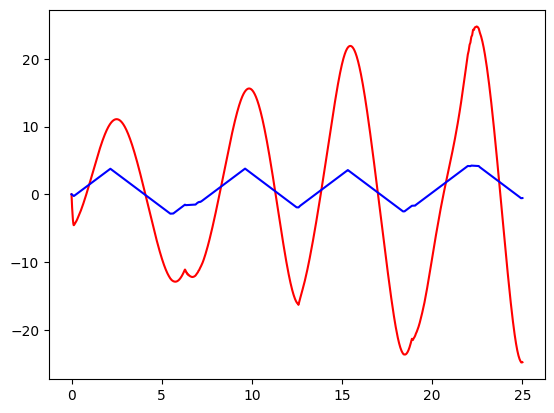

In [69]:
# convergence
# plt.plot(t, x[0], 'b')
# plt.plot(t, x[8], 'r--')
# plt.plot(t, x[1], 'm')
# plt.plot(t, x[9], 'm--')
# plt.plot(t, x[2], 'k')
# plt.plot(t, x[11], 'k--')
# plt.plot(t, x[3], 'b')
# plt.plot(t, x[12], 'b--')
plt.plot(t, x[13], 'r')
plt.plot(t, x[14], 'b')
# plt.ylim([-1, 1])
plt.show()

In [70]:
dist_t = np.array(dist_hist[0][0])
dist_d = np.array(dist_hist[0][1])
dist_d_hat = np.array(dist_hist[0][2])

(-1.0, 1.0)

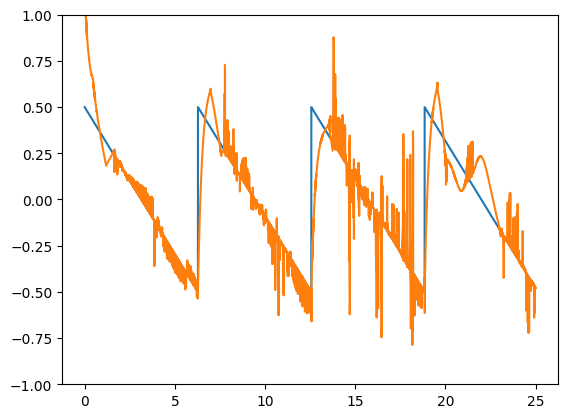

In [71]:
plt.plot(dist_t, dist_d[:, 0])
plt.plot(dist_t, dist_d_hat[:, 0])
plt.ylim([-1, 1])

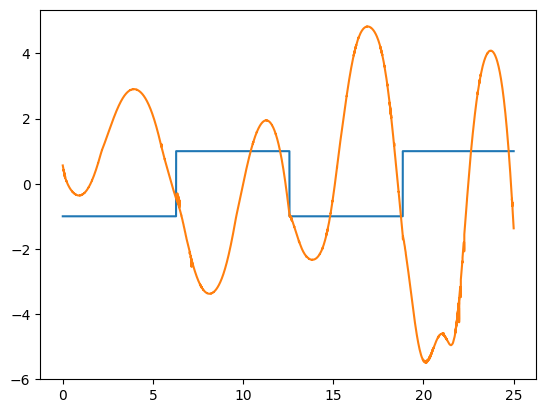

In [72]:
plt.plot(dist_t, dist_d[:, 1])
plt.plot(dist_t, dist_d_hat[:, 1])
# plt.ylim([-2, 2])
# plt.xlim([20, 50])

In [73]:
def rebuild_dist(t, x):
    nx = 4
    id = 0
    id_hat = id + nx

    d_hist = []
    d_hat_hist = []
    Psi_hist = []
    Y_hist = []
    for i in range(len(t)):
        Y_levants = x[:, i][id_hat+nx:] #.reshape and get just the needed info
        x_hat = x[:, i][id_hat:id_hat+nx].reshape(4, 1)
        xx = x[:, i][id:id_hat].reshape(4, 1)

        Psi = Psi_x(xx)
        # Y = np.array([
        #     [Y_levants[2]],
        #     [Y_levants[6]],
        # ]).reshape(2, 1)

        Y = np.array([
            [Y_levants[0]],
            [Y_levants[1]],
        ]).reshape(2, 1)

        d = d_x(t[i])
        d_hat = Gamma_inv(xx)@(Y - Psi)

        d_hist.append(d)
        d_hat_hist.append(d_hat)
        Psi_hist.append(Psi)
        Y_hist.append(Y)
    
    return np.array(d_hist), np.array(d_hat_hist), np.array(Psi_hist), np.array(Y_hist)

# d_hist, d_hat_hist, Psi_hist, Y_list = rebuild_dist(t, x)

In [74]:
# plt.plot(t, Psi_hist[:, 0], 'b')
# plt.plot(t, Y_list[:, 0], 'b--')
# plt.plot(t, Psi_hist[:, 1], 'r')
# plt.plot(t, Y_list[:, 1], 'r--')

# plt.plot(t, Y_list[:, 1] + Psi_hist[:, 1], 'm--')
# plt.show()

In [75]:
def plot_dist(t_dist, dist, dist_hat):
    plt.figure(dpi=150, constrained_layout=True)

    cols = 1
    rows = 2

    for i in range(rows):
        plt.subplot(rows, cols, i+1)
        plt.plot(t_dist, dist[:,i], 'b')
        plt.plot(t_dist, dist_hat[:, i], 'r--')

        # if i == 0:
            # plt.ylim([-100, 100])
    
    plt.show()

# plot_dist(t, d_hist, d_hat_hist)

<>:10: SyntaxWarning: invalid escape sequence '\h'
<>:10: SyntaxWarning: invalid escape sequence '\h'
C:\Users\luiza\AppData\Local\Temp\ipykernel_2028\1948341511.py:10: SyntaxWarning: invalid escape sequence '\h'
  plt.plot(t, x[4+i], 'r--', label=f'$\hat{{x}}_{i+1}$')


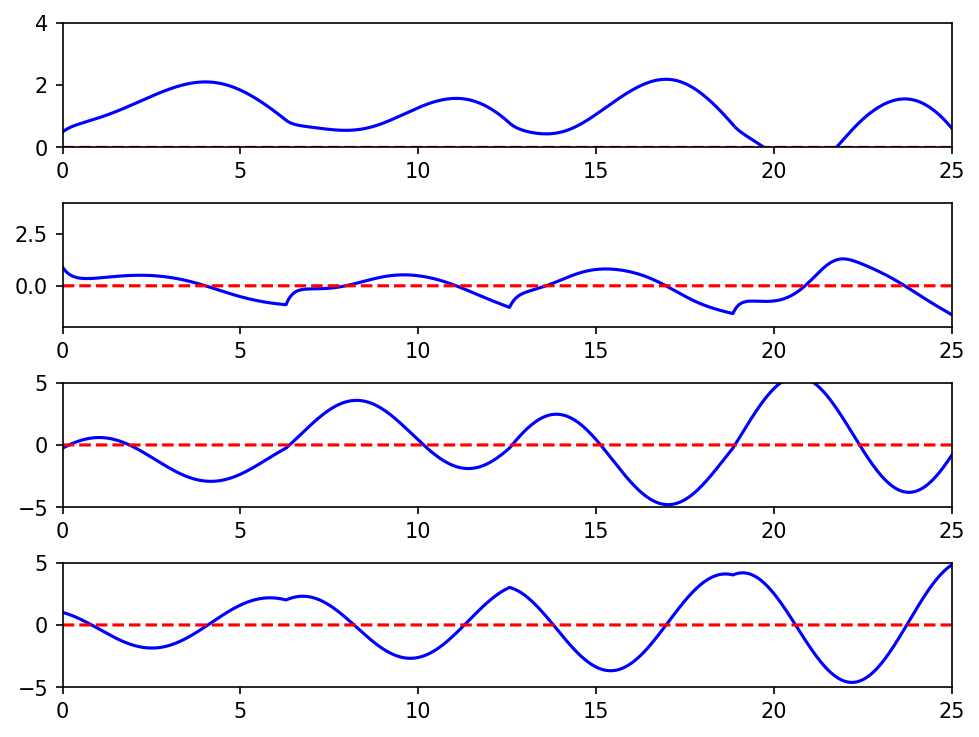

In [76]:
def plot_graph(x, nx):
    plt.figure(dpi=150, constrained_layout=True)

    cols = 1
    rows = nx

    for i in range(rows):
        plt.subplot(rows, cols, i+1)
        plt.plot(t, x[i], 'b', label=f'$x_{i+1}$')
        plt.plot(t, x[4+i], 'r--', label=f'$\hat{{x}}_{i+1}$')
        if i == 0:
            plt.ylim([0, 4])
        elif i == 1:
            plt.ylim([-2, 4])
        elif i == 2:
            plt.ylim([-5, 5])
        else:
            plt.ylim([-5, 5])
        
        plt.xlim([0, time])

    plt.show()

plot_graph(x, 4)
    